In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random

## Epsilon Greedy ##

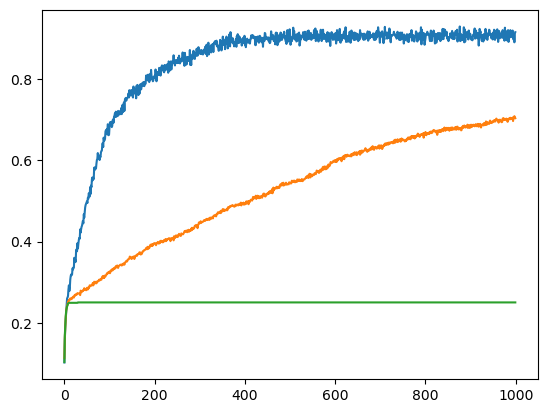

In [39]:
def iterate(epsilon):
    estimates = np.zeros(10)
    truth = np.random.randn(10)
    counts = np.zeros(10)
    track = np.zeros(1000)
    best_lever = np.argmax(truth)
    for i in range(1000):
        num = random.random()
        if num < epsilon:
            lever = np.random.randint(0,10)
        else:
            lever = np.argmax(estimates)
        counts[lever] += 1
        reward = truth[lever] + np.random.normal(0,0.01)
        estimates[lever] = estimates[lever] + (reward - estimates[lever])/counts[lever]
        if lever == best_lever:
            track[i] = 1
        else:
            track[i] = 0
    return track

track_total_high = np.zeros((1000, 1000))
track_total_low = np.zeros((1000, 1000))
track_total_none = np.zeros((1000, 1000))

for i in range(1000):
    track_total_high[i] = iterate(0.1)
    track_total_low[i] = iterate(0.01)
    track_total_none[i] = iterate(0.00)

plt.plot(np.arange(0,1000), np.mean(track_total_high, axis = 0))
plt.plot(np.arange(0,1000), np.mean(track_total_low, axis = 0))
plt.plot(np.arange(0,1000), np.mean(track_total_none, axis = 0))

## Optimistic approach ##

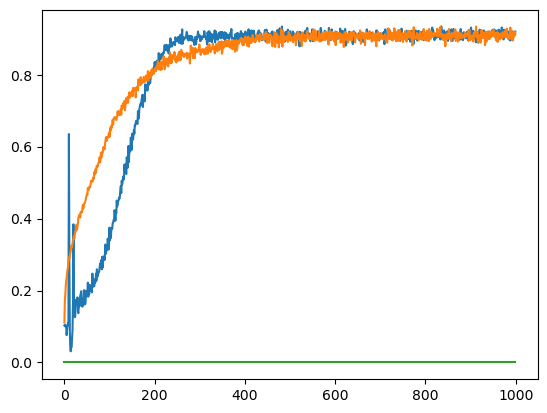

In [ ]:
def iterate_greedy(epsilon):
    estimates = np.full(10, 5.0)
    truth = np.random.randn(10)
    counts = np.zeros(10)
    track = np.zeros(1000)
    step_size = 0.1
    best_lever = np.argmax(truth)
    for i in range(1000):
        num = random.random()
        if num < epsilon:
            lever = np.random.randint(0,10)
        else:
            lever = np.argmax(estimates)
        counts[lever] += 1
        reward = truth[lever] + np.random.normal(0,0.01)
        estimates[lever] = estimates[lever] + step_size * (reward - estimates[lever])
        if lever == best_lever:
            track[i] = 1
        else:
            track[i] = 0
    return track

track_total_high = np.zeros((1000, 1000))
track_total_low = np.zeros((1000, 1000))
track_total_none = np.zeros((1000, 1000))

for i in range(1000):
    track_total_high[i] = iterate_greedy(0.1)
    track_total_low[i] = iterate(0.1)
    #track_total_none[i] = iterate_greedy(0.00)

plt.plot(np.arange(0,1000), np.mean(track_total_high, axis = 0))
plt.plot(np.arange(0,1000), np.mean(track_total_low, axis = 0))
#plt.plot(np.arange(0,1000), np.mean(track_total_none, axis = 0))

## UCB ##


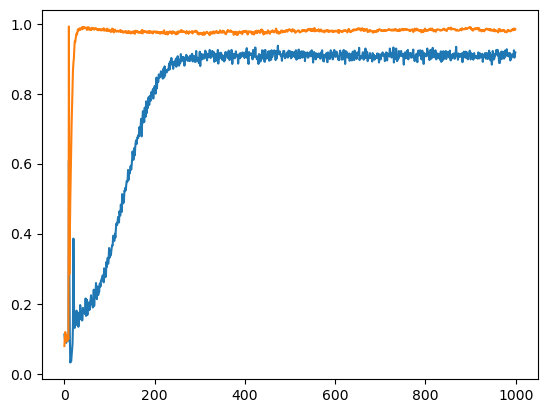

In [ ]:
def iterate_UCB():
    estimates = np.zeros(10, dtype = float)
    truth = np.random.randn(10)
    counts = np.zeros(10)
    track = np.zeros(1000)
    c = 0.5
    step_size = 0.1
    best_lever = np.argmax(truth)
    for i in range(1000):
        if 0 in counts:
            lever = np.argmin(counts)
        else:
            lever = np.argmax(estimates + c * np.sqrt(np.log(i+1)/counts))
        counts[lever] += 1
        reward = truth[lever] + np.random.normal(0,0.01)
        estimates[lever] = estimates[lever] + step_size * (reward - estimates[lever])
        if lever == best_lever:
            track[i] = 1
        else:
            track[i] = 0
        
    return track

track_total_high = np.zeros((1000, 1000))
track_total_low = np.zeros((1000, 1000))
track_total_none = np.zeros((1000, 1000))

for i in range(1000):
    track_total_high[i] = iterate_greedy(0.1)
    track_total_low[i] = iterate_UCB()
    #track_total_none[i] = iterate_greedy(0.00)

plt.plot(np.arange(0,1000), np.mean(track_total_high, axis = 0))
plt.plot(np.arange(0,1000), np.mean(track_total_low, axis = 0))
#plt.plot(np.arange(0,1000), np.mean(track_total_none, axis = 0))

## Gradient Bandit ##

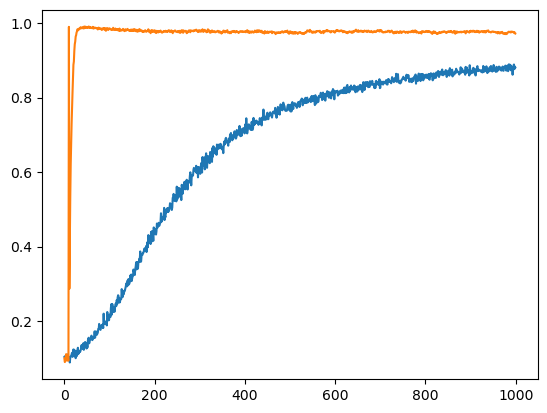

In [58]:
def softmax_gibbs(preference):    
    return np.exp(preference)/np.sum(np.exp(preference))

def iterate_gradient():
    preference = np.zeros(10, dtype = float)
    truth = np.random.randn(10)
    reward_avg = 0.0
    alpha = 0.04
    track = np.zeros(1000)
    best_lever = np.argmax(truth)
    for i in range(1000):
        pi = softmax_gibbs(preference)
        lever = np.random.choice(10, p=pi)
        reward = truth[lever] + np.random.normal(0,0.01)
        for j in range(len(preference)):
            if j is not lever:
                preference[j] = preference[j] - alpha*(reward- reward_avg)*pi[j]
            else:
                preference[j] = preference[j] + alpha*(reward - reward_avg)*(1-pi[j])
        reward_avg = reward_avg * i/(i+1) + reward/(i+1)
        if lever == best_lever:
            track[i] = 1
        else:
            track[i] = 0
    return track
    
track_total = np.zeros((2000,1000))
track_total_low = np.zeros((2000, 1000))
for i in range(2000):
    track_total[i] = iterate_gradient()
    track_total_low[i] = iterate_UCB()
    
plt.plot(np.arange(0,1000), np.mean(track_total, axis = 0))
plt.plot(np.arange(0,1000), np.mean(track_total_low, axis = 0))
